# Emotion recognition using EEG and computer games (+micro:bit)

In [1]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import os

# Constants
SAMPLE_RATE = 32 # (Hz)
GAMES = ["boring", "calm", "horror", "funny"]
SUBJECT_COUNT = 12

## Preprocess the data

1. Read and plot the data.

In [8]:
# Read the data
data = []
for x in range(SUBJECT_COUNT):
    for game_id, game in enumerate(GAMES):
        print(f"printing for S{x+1}G{game_id + 1}AllChannels.csv")
        game_data = pd.read_csv(os.path.join("data", f"S{x+1}G{game_id + 1}AllChannels.csv"))
        game_data["game"] = game
        data.append(game_data)

data = pd.concat(data, axis = 0)

# referencing each file
data.loc[0].head(n=4*SUBJECT_COUNT)

printing for S1G1AllChannels.csv
printing for S1G2AllChannels.csv
printing for S1G3AllChannels.csv
printing for S1G4AllChannels.csv
printing for S2G1AllChannels.csv
printing for S2G2AllChannels.csv
printing for S2G3AllChannels.csv
printing for S2G4AllChannels.csv
printing for S3G1AllChannels.csv
printing for S3G2AllChannels.csv
printing for S3G3AllChannels.csv
printing for S3G4AllChannels.csv
printing for S4G1AllChannels.csv
printing for S4G2AllChannels.csv
printing for S4G3AllChannels.csv
printing for S4G4AllChannels.csv
printing for S5G1AllChannels.csv
printing for S5G2AllChannels.csv
printing for S5G3AllChannels.csv
printing for S5G4AllChannels.csv
printing for S6G1AllChannels.csv
printing for S6G2AllChannels.csv
printing for S6G3AllChannels.csv
printing for S6G4AllChannels.csv
printing for S7G1AllChannels.csv
printing for S7G2AllChannels.csv
printing for S7G3AllChannels.csv
printing for S7G4AllChannels.csv
printing for S8G1AllChannels.csv
printing for S8G2AllChannels.csv
printing f

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,O1,O2,P7,P8,T7,T8,Unnamed: 14,game
0,-33.02050,-15.18460,-42.1795,1.68720,42.17930,-1.68720,-5.54360,-3.61540,25.78990,-9.88190,5.54360,7.47180,11.81010,17.11280,NaN,boring
0,46.51800,9.39990,48.4461,-38.80520,-28.20010,-55.19480,-69.17430,-8.43600,-3.13340,41.69720,131.84090,51.33820,3.13340,-29.64610,NaN,calm
0,52.54340,-33.74360,91.1077,-19.28220,-57.84630,48.20510,1.92840,-11.08700,42.42050,-1.92840,74.23590,-6.26670,22.17420,-4.82050,NaN,horror
0,-3.61540,0.72290,1.2053,5.06170,-5.06170,-5.06170,-16.63080,-1.20530,26.27180,7.47180,12.77450,12.29250,-0.72290,-4.09740,NaN,funny
0,-3.85640,-9.15900,4.8203,0.00000,0.48193,-6.26700,-14.46170,-3.85640,13.97930,-0.48239,5.78460,0.00000,1.92820,0.48193,NaN,boring
0,-0.72313,-16.14870,-3.6152,-247.05130,17.11300,-243.19490,-118.82550,4.57950,-184.38460,0.72313,6.50770,3.61520,7.47160,2.65130,NaN,calm
0,-5.06170,2.65110,16.1484,-167.99490,16.63080,-167.03080,-64.83590,0.24097,-128.94890,-4.09740,2.16920,-0.24097,8.43570,7.47180,NaN,horror
0,-27.95900,14.94360,-2.4101,106.05110,2.41010,90.14360,76.16390,-16.38990,136.90260,-20.72820,-20.72820,20.24630,-16.38990,-37.11810,NaN,funny
0,1.92820,-1.92820,45.7952,-19.28190,103.15900,-242.47160,-85.32290,12.53350,-120.51280,19.28240,-53.02550,-147.02550,77.61060,72.30790,NaN,boring
0,179.80530,-28.44100,28.4410,-115.69230,108.46150,-116.17420,-152.32820,168.71810,-160.04100,172.09250,-94.48190,-136.42050,147.02550,131.60000,NaN,calm


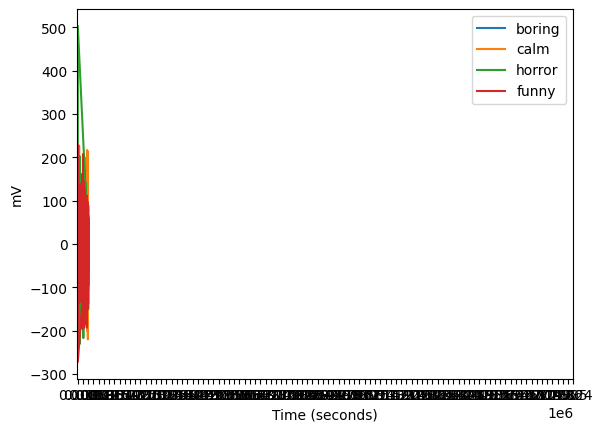

In [9]:
# TODO: choose one of the frontal (F3 / F4 / F7 / F8 / FC5 / FC6) or temporal (T7 / T8) electrodes and ensure the signal is clean
electrode = "T7"

fig, ax = plt.subplots(1, 1)
for game in GAMES:
    ax.plot(data[data["game"] == game][electrode], label = game)
ax.set_xlabel("Time (seconds)")
ax.set_xticks(range(0, len(data), SAMPLE_RATE * 60 * 10))
ax.set_ylabel("mV")

ax.legend()

2. Use the chosen electrode and create a dataset of X-second clips.

In [15]:
# TODO: re-reference the data if needed
# ...

In [12]:
data = data[[electrode, "game"]]
data.loc[0].head(n=4*SUBJECT_COUNT)

,T7,game
0,11.81010,boring
0,3.13340,calm
0,22.17420,horror
0,-0.72290,funny
0,1.92820,boring
0,7.47160,calm
0,8.43570,horror
0,-16.38990,funny
0,77.61060,boring
0,147.02550,calm


In [13]:
# TODO: adjust if needed
clip_length = 2 # (seconds)

# Split into clips
clipped_data = []
y = []
for x in range(SUBJECT_COUNT):
    for game_id, game in enumerate(GAMES):
        clips = np.array_split(
            data[data['game'] == game][electrode].to_numpy(), 
            len(data[data['game'] == game]) // (clip_length * SAMPLE_RATE))
        clipped_data.extend(clips)
        y.extend([game_id] * len(clips))

# Remove edge effects
min_length = np.min([len(arr) for arr in clipped_data])
X = []
for array in clipped_data:
    X.append(array[:min_length])

X = np.vstack(X, dtype = float)
y = np.array(y, dtype = int)

print(X.shape)
print(y.shape)

(344256, 64)
(344256,)


## Train a CNN model

In [14]:
np.random.seed(123)

# Add an additional axis required by torch's Conv layers
X = np.expand_dims(X, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

# Convert to torch tensors
X_train, X_test = torch.Tensor(X_train), torch.Tensor(X_test)
y_train, y_test = torch.Tensor(y_train), torch.Tensor(y_test)

print(X_train.shape)

torch.Size([240979, 1, 64])


In [15]:
class LFPDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y.long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [16]:
# Batch generators

# TODO: adjust if needed
batch_size = 32

train_batch_generator = torch.utils.data.DataLoader(LFPDataset(X_train, y_train), batch_size = batch_size,
                                                    shuffle = True)

test_batch_generator = torch.utils.data.DataLoader(LFPDataset(X_test, y_test), batch_size = batch_size,
                                                    shuffle = False)

In [50]:
# TODO: adjust if needed
model = torch.nn.Sequential(
    torch.nn.Conv1d(1, 1, kernel_size = 4, padding = "same"),
    torch.nn.ReLU(),
    torch.nn.Conv1d(1, 1, kernel_size = 4, padding = "same"),
    torch.nn.ReLU(),
    torch.nn.Conv1d(1, 1, kernel_size = 4, padding = "same"),
    torch.nn.ReLU(),
    torch.nn.Conv1d(1, 1, kernel_size = 4, padding = "same"),
    torch.nn.ReLU(),
    torch.nn.Conv1d(1, 1, kernel_size = 4, padding = "same"),
    torch.nn.ReLU(),
    torch.nn.Conv1d(1, 1, kernel_size = 4, padding = "same"),
    torch.nn.Flatten(),
    torch.nn.Linear(64, 4),
    torch.nn.LogSoftmax(dim = 1)
)

In [51]:
import time

def train(n_epoch, model):
    # TODO: adjust learning rate if needed
    optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

    # total amount of time taken, to be averaged
    total_elapsed_train_time = 0
    total_elapsed_test_time = 0

    # to be plotted
    testing = []
    training = []


    for e in range(n_epoch):
        # time tracking now
        start_time = time.perf_counter()
        model.train(True)

        train_loss = []
        train_acc = []

        for X_batch, y_batch in train_batch_generator:
            model.zero_grad()
            logits = model(X_batch).squeeze()
            loss = torch.nn.functional.nll_loss(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.detach().numpy())
            
            prediction = torch.softmax(logits, dim = 1).detach().numpy()
            prediction = np.argmax(prediction, axis = 1)
            train_acc.append(accuracy_score(y_batch.detach().numpy(), prediction))

        model.train(False)
        test_loss = []
        test_acc = []
        
        # train time done
        end_time = time.perf_counter()
        elapsed_train_time = end_time - start_time
        total_elapsed_train_time = total_elapsed_train_time + elapsed_train_time
        training.append(elapsed_train_time)

        start_time = time.perf_counter()
        
        with torch.no_grad():
            for X_batch, y_batch in test_batch_generator:
                logits = model(X_batch).squeeze()
                loss = torch.nn.functional.nll_loss(logits, y_batch)
                test_loss.append(loss.detach().numpy())

                prediction = torch.softmax(logits, dim = 1).detach().numpy()
                prediction = np.argmax(prediction, axis = 1)
                test_acc.append(accuracy_score(y_batch.detach().numpy(), prediction))

        # test time done, logging elapsed time difference
        end_time = time.perf_counter()
        elapsed_test_time = end_time - start_time
        total_elapsed_test_time = total_elapsed_test_time + elapsed_test_time
        testing.append(elapsed_test_time)

        print(f"Epoch {e} : train_loss={np.mean(train_loss)}, train_acc={np.mean(train_acc)}, test_loss={np.mean(test_loss)}, test_acc={np.mean(test_acc)}")

    print(f"Average training time: {total_elapsed_train_time / n_epoch}, Average testing time: {total_elapsed_test_time / n_epoch}") 
    training.append(total_elapsed_train_time)
    testing.append(total_elapsed_test_time)

    train_df = pd.DataFrame(training)
    test_df = pd.DataFrame(testing)

    train_df.to_csv("training.csv", mode='a')
    test_df.to_csv("testing.csv", mode='a')
    
    return model

In [52]:
train(n_epoch = 10, model = model)

Epoch 0 : train_loss=1.386467695236206, train_acc=0.24827685915758727, test_loss=1.3864150047302246, test_acc=0.24916595176818226
Epoch 1 : train_loss=1.3863606452941895, train_acc=0.2510902305558079, test_loss=1.386279821395874, test_acc=0.25595823205604806
Epoch 2 : train_loss=1.3863214254379272, train_acc=0.2517917170432388, test_loss=1.3862818479537964, test_acc=0.2527195929844629
Epoch 3 : train_loss=1.386231780052185, train_acc=0.253974362110295, test_loss=1.3862264156341553, test_acc=0.24759838790391767
Epoch 4 : train_loss=1.3861688375473022, train_acc=0.2526052404447582, test_loss=1.3860868215560913, test_acc=0.2575838814221714
Epoch 5 : train_loss=1.3859562873840332, train_acc=0.25492023321149776, test_loss=1.385819673538208, test_acc=0.25735600753026405
Epoch 6 : train_loss=1.3854883909225464, train_acc=0.2583866072863742, test_loss=1.3851501941680908, test_acc=0.26120901248689354
Epoch 7 : train_loss=1.3823012113571167, train_acc=0.26389039339152554, test_loss=1.37753427028

Sequential(
  (0): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=same)
  (1): ReLU()
  (2): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=same)
  (3): ReLU()
  (4): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=same)
  (5): ReLU()
  (6): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=same)
  (7): ReLU()
  (8): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=same)
  (9): ReLU()
  (10): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=same)
  (11): Flatten(start_dim=1, end_dim=-1)
  (12): Linear(in_features=64, out_features=4, bias=True)
  (13): LogSoftmax(dim=1)
)

## Make a prediction and project to the micro:bit

In [25]:
pip install pyserial


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


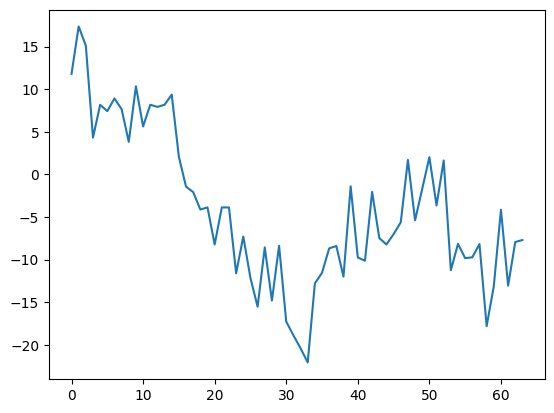

In [26]:
a_clip = X[0]
plt.plot(a_clip.flatten())

In [27]:
prediction = model(torch.tensor(np.expand_dims(a_clip, 1)).float())
prediction = torch.softmax(prediction, dim = 1).detach().numpy()
prediction = int(np.argmax(prediction, axis = 1)[0])

GAMES[prediction]

'horror'

In [28]:
# TODO: your code for projecting to the micro:bit
# ...
GAMES = ["boring", "calm", "horror", "funny"]

def project_emotion(emotion):
    icons = {
        "boring": "😴",
        "calm": "❤️",
        "horror": "💀",
        "funny": "🙂"
    }
    print(f"Predicted emotion: {emotion}")
    print(f"Projected image: {icons[emotion]}")

project_emotion(GAMES[prediction])


Predicted emotion: horror
Projected image: 💀
